<a href="https://colab.research.google.com/github/KarlaMichelleSorianoSanhez/Simulacion-I/blob/main/t%C3%A9cnicas_de_remuestreo_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#TÉCNICAS DE REMUESTREO

## BOOTSTRAP


**NOMBRE**: Karla Michelle Soriano Sánchez

**INSTRUCCIONES**:  Utilizar la muestra obsrvada

$$
\{35,42,38,40,45,37,39,41,44,36,43,40\}
$$

para aplicar la técnica de remuestreo Bootstrap.

A partir de la muestra original se deberán generar 1000 muestras Bootstrap de tamaño 12 utilizando muestreo con reemplazo.

Para cada muestra Bootstrap $B$ se calculará la media muestral.

Finalmente se deberá:

- Obtener la media de las 1000 medias Bootstrap.
- Calcular la desviación estándar Bootstrap.
- Determinar los percentiles 2.5% y 97.5%.
- Construir un intervalo de confianza Bootstrap del 95%.
- Interpretar los resultados obtenidos.


**OBJETIVO**: Aplicar la técnica Bootstrap para estudiar la variabilidad de la media a partir de una muestra observada.

Mediante remuestreo con reemplazo se construirá una aproximación de la distribución muestral de la media y se obtendrá un intervalo de confianza del 95%.

### Fundamento teórico
**Técnicas de Remuestreo**

Las técnicas de remuestreo permiten estudiar el comportamiento de un estimador utilizando únicamente la información contenida en una muestra observada.

La idea consiste en generar nuevas muestras a partir de los datos originales y analizar la variabilidad del estadístico de interés.



**Método Bootstrap**

Supongamos que

$$
X_1,X_2,\ldots,X_n
$$

son variables aleatorias independientes con función de distribución común

$$
F.
$$

Se desea estimar un parámetro poblacional

$$
\theta(F)
$$

mediante un estimador

$$
g(X_1,X_2,\ldots,X_n).
$$

La calidad del estimador puede evaluarse mediante el Error Cuadrático Medio (ECM), definido por

$$
ECM(F)
=
E_F
\left[
\left(
g(X_1,\ldots,X_n)-\theta(F)
\right)^2
\right].
$$

Sin embargo, en la práctica la distribución poblacional

$$
F
$$

generalmente es desconocida.

Por esta razón, el método Bootstrap propone sustituir la distribución poblacional por una aproximación construida a partir de los propios datos observados.


**Distribución Empírica**

Sea

$$
x_1,x_2,\ldots,x_n
$$

la muestra observada.

La distribución empírica se define como

$$
F_n(x)
=
\frac{
\text{Número de observaciones } X_i \le x
}
{n}.
$$

Esta distribución asigna la misma probabilidad a cada observación de la muestra y se utiliza como aproximación de la distribución poblacional.

**Idea Fundamental del Método Bootstrap**

Bootstrap utiliza la distribución empírica como sustituto de la distribución poblacional desconocida.

El procedimiento consiste en:

1. Tomar la muestra original.
2. Generar una remuestra de igual tamaño con reemplazo. Esto significa que después de seleccionar un dato, éste regresa nuevamente a la muestra original y puede ser elegido otra vez.
Por lo tanto, una misma observación puede aparecer varias veces dentro de una misma remuestra Bootstrap, mientras que otras observaciones podrían no aparecer.
3. Calcular el estadístico de interés.
4. Repetir el proceso muchas veces.
5. Analizar la distribución obtenida.

El estadístico de interés será la media muestral.



**Datos de la Muestra**

La muestra observada es

$$
\{35,42,38,40,45,37,39,41,44,36,43,40\}.
$$

Su tamaño es

$$
n=12.
$$

Se generarán

$$
B=1000
$$

remuestras Bootstrap para estudiar la variabilidad de la media.


**Planteamiento del Procedimiento**

Cada remuestra Bootstrap tendrá tamaño

$$
n=12.
$$

Como el muestreo se realiza con reemplazo, una observación puede aparecer varias veces dentro de una remuestra.

Para cada remuestra se calculará la media muestral

$$
\bar X^{*}.
$$

Las 1000 medias obtenidas permitirán aproximar la distribución muestral de la media y construir un intervalo de confianza Bootstrap del 95%.

In [65]:
# Importación de bibliotecas

import numpy as np  #facilitará los cálculos numéricos y la generación de remuestras Bootstrap
import matplotlib.pyplot as  ptl #representar gráficamente la distribución de las medias obtenidas

In [66]:
#muestra observada
datos = np.array(
    [35, 42, 38, 40, 45, 37, 39, 41, 44, 36, 43, 40]
)

# Mostrar la muestra
datos

array([35, 42, 38, 40, 45, 37, 39, 41, 44, 36, 43, 40])

**Parámetros**

Se utilizarán

$$
B=1000
$$

remuestras Bootstrap de tamaño

$$
n=12.
$$


In [67]:
# Número de réplicas Bootstrap
B = 1000

# Tamaño de la muestra original
n = len(datos)

print("Tamaño de la muestra:", n)
print("Número de réplicas Bootstrap:", B)

Tamaño de la muestra: 12
Número de réplicas Bootstrap: 1000


**Generación de las muestras**

Para cada una de las

$$
B=1000
$$

remuestras Bootstrap se calcula la media muestral

$$
\bar X^{*}.
$$

Las medias obtenidas se almacenan para construir una aproximación de la distribución muestral de la media.

In [68]:
# Lista donde se almacenarán las medias Bootstrap
medias_bootstrap = []

# Generación de las remuestras Bootstrap
for i in range(B):
  # Generar una remuestra Bootstrap de tamaño n
  muestra_bootstrap = np.random.choice(
      datos,
      size=n,
      replace=True
    )

  # Calcular la media de la remuestra
  media_muestra = np.mean(muestra_bootstrap)

  # Almacenar la media obtenida
  medias_bootstrap.append(media_muestra)

# Convertir la lista a arreglo NumPy
medias_bootstrap = np.array(medias_bootstrap)

**Medias**

Cada valor almacenado en el arreglo


$$
\bar X_1^{*},
\bar X_2^{*},
\ldots,
\bar X_{1000}^{*}
$$corresponde a la media obtenida a partir de una remuestra Bootstrap.

El conjunto de estas medias constituye una aproximación de la distribución muestral de la media.

In [69]:
# Mostrar las primeras medias Bootstrap

print("Primeras 10 medias Bootstrap:\n")

print(medias_bootstrap[:10])

Primeras 10 medias Bootstrap:

[41.         41.16666667 39.08333333 39.33333333 39.58333333 39.75
 39.58333333 41.5        41.33333333 40.5       ]


**Cálculo de los estadísticos**

Una vez obtenida la distribución Bootstrap de la media, se procede a calcular:

- La media Bootstrap.
- La desviación estándar Bootstrap.
- El percentil 2.5%.
- El percentil 97.5%.

Estos valores permitirán cuantificar la variabilidad de la media y construir posteriormente un intervalo de confianza Bootstrap del 95%.


In [70]:
# Media Bootstrap
media_boot = np.mean(medias_bootstrap)

# Desviación estándar Bootstrap
error_boot = np.std( medias_bootstrap, ddof=1 )

# Percentiles para el intervalo de confianza
p2_5 = np.percentile( medias_bootstrap, 2.5 )

p97_5 = np.percentile( medias_bootstrap, 97.5 )



In [71]:
# Mostrar resultados Bootstrap

print("RESULTADOS DEL MÉTODO BOOTSTRAP")

print(f"Tamaño de muestra (n): {n}")
print(f"Número de réplicas Bootstrap (B): {B}")


print(f"Media Bootstrap: {media_boot:.4f}")
print(f"Desviación estándar Bootstrap: {error_boot:.4f}")

print("\nIntervalo de confianza Bootstrap (95%)")

print(f"Percentil 2.5% : {p2_5:.4f}")
print(f"Percentil 97.5% : {p97_5:.4f}")

print(
    f"\nIC Bootstrap 95% = "
    f"[{p2_5:.4f}, {p97_5:.4f}]"
)

RESULTADOS DEL MÉTODO BOOTSTRAP
Tamaño de muestra (n): 12
Número de réplicas Bootstrap (B): 1000
Media Bootstrap: 40.0005
Desviación estándar Bootstrap: 0.8813

Intervalo de confianza Bootstrap (95%)
Percentil 2.5% : 38.3333
Percentil 97.5% : 41.7500

IC Bootstrap 95% = [38.3333, 41.7500]


**Intervalo de confianza**

Se utilizará el método percentil.

Sean

$$
P_{2.5}
$$

y

$$
P_{97.5}.
$$

Entonces el intervalo Bootstrap al 95% está dado por

$$
IC_{95\%}
=
(P_{2.5},P_{97.5}).
$$

In [72]:
print("INTERVALO DE CONFIANZA BOOTSTRAP AL 95%")
print(f"IC95% = ({p2_5:.4f}, {p97_5:.4f})" )

INTERVALO DE CONFIANZA BOOTSTRAP AL 95%
IC95% = (38.3333, 41.7500)


**Distribución Bootstrap de la Media**

La siguiente gráfica muestra la distribución de las medias Bootstrap obtenidas a partir de las 1000 remuestras.

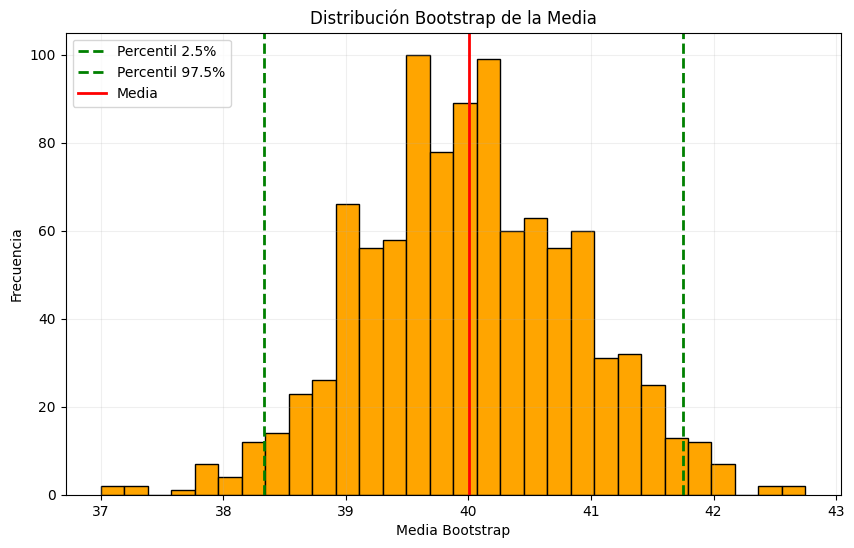

In [73]:
# Histograma de las medias Bootstrap
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

plt.hist(
    medias_bootstrap,
    bins=30,
    color="orange",
    edgecolor="black"
)

# Percentil 2.5%
plt.axvline(
    p2_5,
    color="green",
    linestyle="--",
    linewidth=2,
    label="Percentil 2.5%"
)

# Percentil 97.5%
plt.axvline(p97_5, color="green",linestyle="--", linewidth=2, label="Percentil 97.5%")

# Media Bootstrap
plt.axvline( media_boot,color="red", linestyle="-", linewidth=2, label="Media")

plt.title("Distribución Bootstrap de la Media")
plt.xlabel("Media Bootstrap")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

La gráfica muestra la distribución de las 1000 medias Bootstrap obtenidas a partir de las remuestras generadas.

La línea roja representa la media Bootstrap, mientras que las líneas verdes indican los percentiles 2.5% y 97.5% utilizados para construir el intervalo de confianza Bootstrap del 95%.

### Solución analitica  

Consideremos la muestra observada

$$
\{35,42,38,40,45,37,39,41,44,36,43,40\}.
$$

La media muestral es

$$
\bar{x}
=
\frac{35+42+38+40+45+37+39+41+44+36+43+40}{12}
=
40.
$$

En Bootstrap cada observación tiene la misma probabilidad de ser seleccionada en una remuestra, es decir,

$$
P(X^*=x_i)=\frac{1}{12},
\qquad i=1,\ldots,12.
$$

Por lo tanto, el valor esperado de la distribución empírica coincide con la media muestral:

$$
E(X^*)
=
\frac{1}{12}
\sum_{i=1}^{12}x_i
=
40.
$$


Para calcular la variabilidad de la distribución empírica obtenemos primero la suma de desviaciones cuadráticas respecto a la media:

$$
\sum_{i=1}^{12}(x_i-\bar{x})^2
=
110.
$$

De esta forma,

$$
Var(X^*)
=
\frac{110}{12}
=
9.1667.
$$

Sea ahora

$$
\bar{X}^{*}
=
\frac{1}{12}
\sum_{j=1}^{12}X_j^{*},
$$

la media obtenida a partir de una remuestra Bootstrap.

Como las observaciones remuestreadas son independientes,

$$
Var(\bar{X}^{*})
=
\frac{Var(X^*)}{12}
=
\frac{9.1667}{12}
=
0.7639.
$$

Por lo tanto, la desviación estándar es

$$
\sigma_{\bar{X}^{*}}
=
\sqrt{0.7639}
\approx
0.874.
$$


Utilizando una aproximación normal, un intervalo de confianza bilateral del 95% para la media está dado por

$$
\bar{x}
\pm
z_{0.975}\sigma_{\bar{X}^{*}},
$$

donde

$$
z_{0.975}=1.96.
$$

Sustituyendo los valores obtenidos:

$$
40
\pm
1.96(0.874)
=
40
\pm
1.713.
$$

Por lo tanto,

$$
IC_{95\%}
=
(38.287,\;41.713).
$$

Observamos que este intervalo es muy cercano al intervalo obtenido mediante Bootstrap, lo cual indica que la simulación reproduce adecuadamente el comportamiento esperado de la media.


**Conslusión**

Finalamente desoues de aplicar la técnica Bootstrap a una muestra de 12 tiempos de entrega, generando 1000 remuestras con reemplazo para aproximar la distribución muestral de la media.

A partir de las remuestras se obtuvo la media Bootstrap, su desviación estándar y un intervalo de confianza del 95% mediante el método percentil.

Al comparar los resultados de la simulación con la solución analítica, se observa que ambos intervalos de confianza son muy similares, lo que confirma que el procedimiento Bootstrap proporciona una buena aproximación para estudiar la variabilidad y la precisión de la media utilizando únicamente la información contenida en la muestra observada.

##JACKKNIFE

**INSTRUCCIÓN** :
Utilizar la muestra observada

$$
\{35,42,38,40,45,37,39,41,44,36,43,40\}
$$

para aplicar la técnica de remuestreo Jackknife.

A partir de la muestra original se generarán muestras de tamaño

$$
n-1
$$

eliminando una observación a la vez.

Para cada muestra se calculará la media muestral.

Finalmente se obtendrán:

- Las medias Jackknife.
- El promedio Jackknife.
- La varianza Jackknife.
- El error estándar Jackknife.
- Un intervalo de confianza del 95%.
- La interpretación de los resultados.

**OBJETIVO** : Aplicar la técnica Jackknife para estimar la variabilidad de la media utilizando la información contenida en una muestra observada.

Mediante la eliminación sistemática de una observación a la vez se obtendrá una estimación del error estándar y un intervalo de confianza para la media.

### Fundamento Teórico
Jackknife es una técnica de remuestreo que consiste en eliminar una observación de la muestra y calcular nuevamente el estadístico de interés.

Este procedimiento se repite para cada observación de la muestra, generando así

$$
n
$$

muestras de tamaño

$$
n-1.
$$

El método permite estimar la variabilidad de un estimador sin necesidad de realizar supuestos sobre la distribución poblacional.



### Promedio Jackknife

Sea

$$
\hat{\theta}_1,\hat{\theta}_2,\ldots,\hat{\theta}_n
$$

los valores obtenidos para el estadístico de interés al eliminar una observación a la vez.

El promedio Jackknife se define como

$$
\hat{\theta}
=
\frac{1}{n}
\sum_{i=1}^{n}
\hat{\theta}_i.
$$

En esta actividad el estadístico de interés será la media muestral.


### Varianza Jackknife

Una vez calculadas las

$$
n
$$

estimaciones Jackknife, la varianza se obtiene mediante

$$
\operatorname{Var}_{J}
=
\frac{n-1}{n}
\sum_{i=1}^{n}
\left(
\hat{\theta}
-
\hat{\theta}_i
\right)^2.
$$

Esta expresión permite cuantificar la variabilidad del estimador.


### Error Estándar Jackknife

El error estándar Jackknife se calcula como la raíz cuadrada de la varianza Jackknife:

$$
SE_J
=
\sqrt{
\operatorname{Var}_{J}
}.
$$

Esta cantidad mide la incertidumbre asociada a la estimación realizada.


### Intervalo de Confianza

Utilizando una aproximación normal, un intervalo de confianza del 95% para la media puede construirse mediante

$$
\hat{\theta}
\pm
1.96\,SE_J.
$$

Este intervalo proporciona un rango de valores plausibles para la media poblacional.



## Datos de la Muestra

La muestra utilizada en esta actividad corresponde a los tiempos de entrega:

$$
\{35,42,38,40,45,37,39,41,44,36,43,40\}.
$$

El tamaño de la muestra es

$$
n=12.
$$

Como el método Jackknife elimina una observación a la vez, se generarán

$$
12
$$

muestras de tamaño

$$
11.
$$


Se eliminará cada observación de la muestra una sola vez para generar las muestras Jackknife.

Para cada una de ellas se calculará la media muestral.

Posteriormente se obtendrán el promedio Jackknife, la varianza Jackknife, el error estándar y el intervalo de confianza correspondiente.

## Solución Analítica

Consideremos la muestra observada

$$
\{35,42,38,40,45,37,39,41,44,36,43,40\}.
$$

El tamaño de la muestra es

$$
n=12.
$$

La media muestral original es

$$
\bar{x}
=
\frac{35+42+38+40+45+37+39+41+44+36+43+40}{12}
=
40.
$$

Aplicaremos ahora el procedimiento Jackknife eliminando una observación a la vez.

### Muestras Jackknife

Al eliminar cada observación se obtienen las siguientes muestras de tamaño

$$
n-1=11.
$$

**Muestra 1 (sin el 35)**

$$
\{42,38,40,45,37,39,41,44,36,43,40\}
$$

$$
\hat{\theta}_1
=
\frac{445}{11}
=
40.4545
$$

**Muestra 2 (sin el 42)**

$$
\{35,38,40,45,37,39,41,44,36,43,40\}
$$

$$
\hat{\theta}_2
=
\frac{438}{11}
=
39.8182
$$

**Muestra 3 (sin el 38)**

$$
\hat{\theta}_3
=
\frac{442}{11}
=
40.1818
$$

**Muestra 4 (sin el 40)**

$$
\hat{\theta}_4
=
\frac{440}{11}
=
40.0000
$$

**Muestra 5 (sin el 45)**

$$
\hat{\theta}_5
=
\frac{435}{11}
=
39.5455
$$

**Muestra 6 (sin el 37)**

$$
\hat{\theta}_6
=
\frac{443}{11}
=
40.2727
$$

**Muestra 7 (sin el 39)**

$$
\hat{\theta}_7
=
\frac{441}{11}
=
40.0909
$$

**Muestra 8 (sin el 41)**

$$
\hat{\theta}_8
=
\frac{439}{11}
=
39.9091
$$

**Muestra 9 (sin el 44)**

$$
\hat{\theta}_9
=
\frac{436}{11}
=
39.6364
$$

**Muestra 10 (sin el 36)**

$$
\hat{\theta}_{10}
=
\frac{444}{11}
=
40.3636
$$

**Muestra 11 (sin el 43)**

$$
\hat{\theta}_{11}
=
\frac{437}{11}
=
39.7273
$$

**Muestra 12 (sin el segundo 40)**

$$
\hat{\theta}_{12}
=
\frac{440}{11}
=
40.0000
$$

### Promedio Jackknife

De acuerdo con la definición presentada anteriormente,

$$
\hat{\theta}
=
\frac{1}{n}
\sum_{i=1}^{n}
\hat{\theta}_i.
$$

Sustituyendo los valores obtenidos,

$$
\hat{\theta}
=
\frac{
40.4545+
39.8182+
40.1818+
40+
39.5455+
40.2727+
40.0909+
39.9091+
39.6364+
40.3636+
39.7273+
40
}{12}.
$$

Por lo tanto,

$$
\hat{\theta}
=
40.
$$

Observamos que el promedio Jackknife coincide con la media de la muestra original.

### Varianza Jackknife

La varianza Jackknife está dada por

$$
\operatorname{Var}_{J}
=
\frac{n-1}{n}
\sum_{i=1}^{n}
\left(
\hat{\theta}
-
\hat{\theta}_i
\right)^2.
$$

Como

$$
n=12
$$

y

$$
\hat{\theta}=40,
$$

obtenemos

$$
\operatorname{Var}_{J}
=
\frac{11}{12}
\sum_{i=1}^{12}
(40-\hat{\theta}_i)^2.
$$

Calculando las desviaciones cuadráticas:

$$
\sum_{i=1}^{12}
(40-\hat{\theta}_i)^2
=
0.7639.
$$

Por lo tanto,

$$
\operatorname{Var}_{J}
=
\frac{11}{12}(0.7639)
=
0.7002.
$$

### Error Estándar Jackknife

El error estándar Jackknife se obtiene como

$$
SE_J
=
\sqrt{\operatorname{Var}_{J}}.
$$

Sustituyendo el valor calculado,

$$
SE_J
=
\sqrt{0.7002}
=
0.8368.
$$

### Intervalo de Confianza del 95%

Utilizando una aproximación normal,

$$
IC_{95\%}
=
\hat{\theta}
\pm
1.96\,SE_J.
$$

Sustituyendo los valores obtenidos,

$$
IC_{95\%}
=
40
\pm
1.96(0.8368).
$$

Entonces,

$$
IC_{95\%}
=
40
\pm
1.6399.
$$

Finalmente,

$$
IC_{95\%}
=
(38.3601,\;41.6399).
$$



El promedio Jackknife obtenido coincide con la media de la muestra original, lo que indica que el procedimiento conserva adecuadamente la información contenida en los datos.

La varianza y el error estándar Jackknife proporcionan una medida de la variabilidad de la media cuando se elimina una observación a la vez.

Además, el intervalo de confianza obtenido permite identificar un rango plausible para la media poblacional de los tiempos de entrega.

## Simulación

Para aplicar el método Jackknife utilizaremos la muestra observada y generaremos automáticamente las 12 muestras de tamaño

$$
n-1=11
$$

eliminando una observación a la vez.

Posteriormente se calcularán las medias Jackknife, el promedio Jackknife, la varianza, el error estándar y el intervalo de confianza del 95%.


In [74]:
import numpy as np
import matplotlib.pyplot as plt

## Definición de la Muestra
datos = np.array(
    [35, 42, 38, 40, 45, 37, 39, 41, 44, 36, 43, 40]
)



## Generación de las Muestras Jackknife

El procedimiento Jackknife consiste en eliminar una observación a la vez.

Como la muestra contiene

$$
n=12
$$

observaciones, se obtendrán 12 muestras de tamaño 11.

Para cada muestra se calculará la media correspondiente.

In [75]:
# Número de observaciones
n = len(datos)

# Lista donde se almacenarán las medias Jackknife
medias_jackknife = []

# Generación de las muestras Jackknife
for i in range(n):
  # Eliminar la observación i
  muestra_jackknife = np.delete(datos, i)

  # Calcular la media de la muestra
  media = np.mean(muestra_jackknife)

  # Guardar la media obtenida
  medias_jackknife.append(media)

# Convertir a arreglo de NumPy
medias_jackknife = np.array(medias_jackknife)

## Medias Jackknife Obtenidas

Las medias calculadas constituyen las estimaciones

$$
\hat{\theta}_1,\hat{\theta}_2,\ldots,\hat{\theta}_{12}
$$

utilizadas para construir los estimadores Jackknife.

In [76]:
for i, media in enumerate(medias_jackknife, start=1):
  print(f"Media Jackknife {i}: {media:.4f}" )

Media Jackknife 1: 40.4545
Media Jackknife 2: 39.8182
Media Jackknife 3: 40.1818
Media Jackknife 4: 40.0000
Media Jackknife 5: 39.5455
Media Jackknife 6: 40.2727
Media Jackknife 7: 40.0909
Media Jackknife 8: 39.9091
Media Jackknife 9: 39.6364
Media Jackknife 10: 40.3636
Media Jackknife 11: 39.7273
Media Jackknife 12: 40.0000


## Cálculo de los Estadísticos Jackknife

Una vez obtenidas las medias Jackknife se calcularán:

- El promedio Jackknife.
- La varianza Jackknife.
- El error estándar Jackknife.
- El intervalo de confianza del 95%.

In [77]:
# Promedio Jackknife
theta_j = np.mean(medias_jackknife)

# Varianza Jackknife
var_j = ((n - 1) / n) * np.sum(
    (theta_j - medias_jackknife) ** 2 )

# Error estándar Jackknife
se_j = np.sqrt(var_j)

# Intervalo de confianza al 95%
li = theta_j - 1.96 * se_j
ls = theta_j + 1.96 * se_j

In [78]:
print("RESULTADOS DEL MÉTODO JACKKNIFE")

print(f"Promedio Jackknife       : {theta_j:.4f}")
print(f"Varianza Jackknife       : {var_j:.4f}")
print(f"Error estándar Jackknife : {se_j:.4f}")

print("\nIntervalo de confianza al 95%")
print("-" * 50)

print(f"IC95% = ({li:.4f}, {ls:.4f})")

RESULTADOS DEL MÉTODO JACKKNIFE
Promedio Jackknife       : 40.0000
Varianza Jackknife       : 0.8333
Error estándar Jackknife : 0.9129

Intervalo de confianza al 95%
--------------------------------------------------
IC95% = (38.2108, 41.7892)


## Grafica de las Medias Jackknife
Para visualizar la variabilidad de las medias Jackknife se construira un histograma.

Además se mostrarán:

- El promedio Jackknife.
- Los límites del intervalo de confianza.

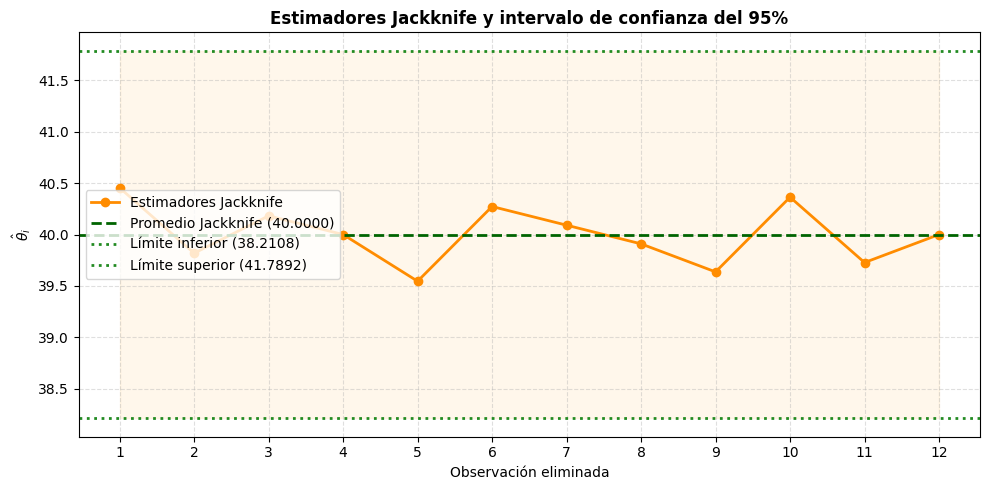

In [79]:
# Gráfica de los estimadores Jackknife

plt.figure(figsize=(10,5))

# Observaciones eliminadas
x = np.arange(1, n + 1)

# Estimadores Jackknife
plt.plot(x, medias_jackknife, marker='o', color='darkorange',
    linewidth=2, label='Estimadores Jackknife')

# Promedio Jackknife
plt.axhline( theta_j, color='darkgreen',linestyle='--',
    linewidth=2, label=f'Promedio Jackknife ({theta_j:.4f})')

# Límite inferior
plt.axhline( li, color='forestgreen', linestyle=':',
    linewidth=2, label=f'Límite inferior ({li:.4f})')

# Límite superior
plt.axhline( ls,color='forestgreen',linestyle=':',
    linewidth=2, label=f'Límite superior ({ls:.4f})')

# Región del intervalo de confianza
plt.fill_between( x, li, ls, color='orange', alpha=0.08 )

plt.title(
    'Estimadores Jackknife y intervalo de confianza del 95%',
    fontweight='bold'
)

plt.xlabel('Observación eliminada')
plt.ylabel(r'$\hat{\theta}_i$')

plt.xticks(x)

plt.grid(
    True,
    linestyle='--',
    alpha=0.4
)

plt.legend(loc='center left')

plt.tight_layout()

plt.show()

La gráfica muestra las 12 estimaciones Jackknife obtenidas al eliminar una observación de la muestra original.

Se observa que todas las estimaciones permanecen cercanas al promedio Jackknife y dentro del intervalo de confianza calculado.

Esto indica que la media es relativamente estable frente a pequeñas modificaciones en la muestra y que ninguna observación individual ejerce una influencia excesiva sobre la estimación.

## Conclusiones

En esta actividad se aplicó la técnica Jackknife a una muestra de 12 tiempos de entrega, generando 12 muestras de tamaño 11 al eliminar una observación a la vez.

Con las medias obtenidas se calcularon el promedio Jackknife, la varianza, el error estándar y un intervalo de confianza del 95%.

Los resultados muestran que la media es estable frente a pequeñas modificaciones en la muestra, ya que las estimaciones obtenidas presentan poca variabilidad.

En conclusión, el método Jackknife es una herramienta sencilla y útil para evaluar la precisión y estabilidad de un estimador utilizando únicamente los datos observados.